<center><h1>Patchou_Brice_HW1</h1></center>
<br>
<center><font size="4">Vertebral Column Data</font></center>

### (a) Download Data

Package imports

In [96]:
# AI prompt:
# You will act as a TA. Do not explictly give me any anwsers but please do give me hints and guide me to the correct answer.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.io import arff
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, f1_score



Get the Vertebral Column Data Set

In [49]:
arff_file = arff.loadarff('vertebral_column_data/column_2C_weka.arff')
df = pd.DataFrame(arff_file[0])

### (b) Pre-Processing and Exploratory Data Analysis

#### i. Scatterplots

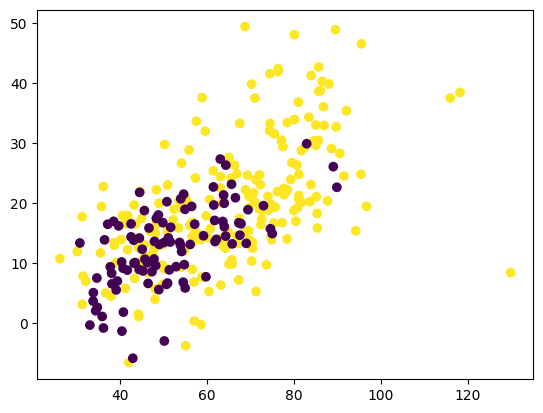

array([[<Axes: xlabel='pelvic_incidence', ylabel='pelvic_incidence'>,
        <Axes: xlabel='pelvic_tilt', ylabel='pelvic_incidence'>,
        <Axes: xlabel='lumbar_lordosis_angle', ylabel='pelvic_incidence'>,
        <Axes: xlabel='sacral_slope', ylabel='pelvic_incidence'>,
        <Axes: xlabel='pelvic_radius', ylabel='pelvic_incidence'>,
        <Axes: xlabel='degree_spondylolisthesis', ylabel='pelvic_incidence'>],
       [<Axes: xlabel='pelvic_incidence', ylabel='pelvic_tilt'>,
        <Axes: xlabel='pelvic_tilt', ylabel='pelvic_tilt'>,
        <Axes: xlabel='lumbar_lordosis_angle', ylabel='pelvic_tilt'>,
        <Axes: xlabel='sacral_slope', ylabel='pelvic_tilt'>,
        <Axes: xlabel='pelvic_radius', ylabel='pelvic_tilt'>,
        <Axes: xlabel='degree_spondylolisthesis', ylabel='pelvic_tilt'>],
       [<Axes: xlabel='pelvic_incidence', ylabel='lumbar_lordosis_angle'>,
        <Axes: xlabel='pelvic_tilt', ylabel='lumbar_lordosis_angle'>,
        <Axes: xlabel='lumbar_lordosis_an

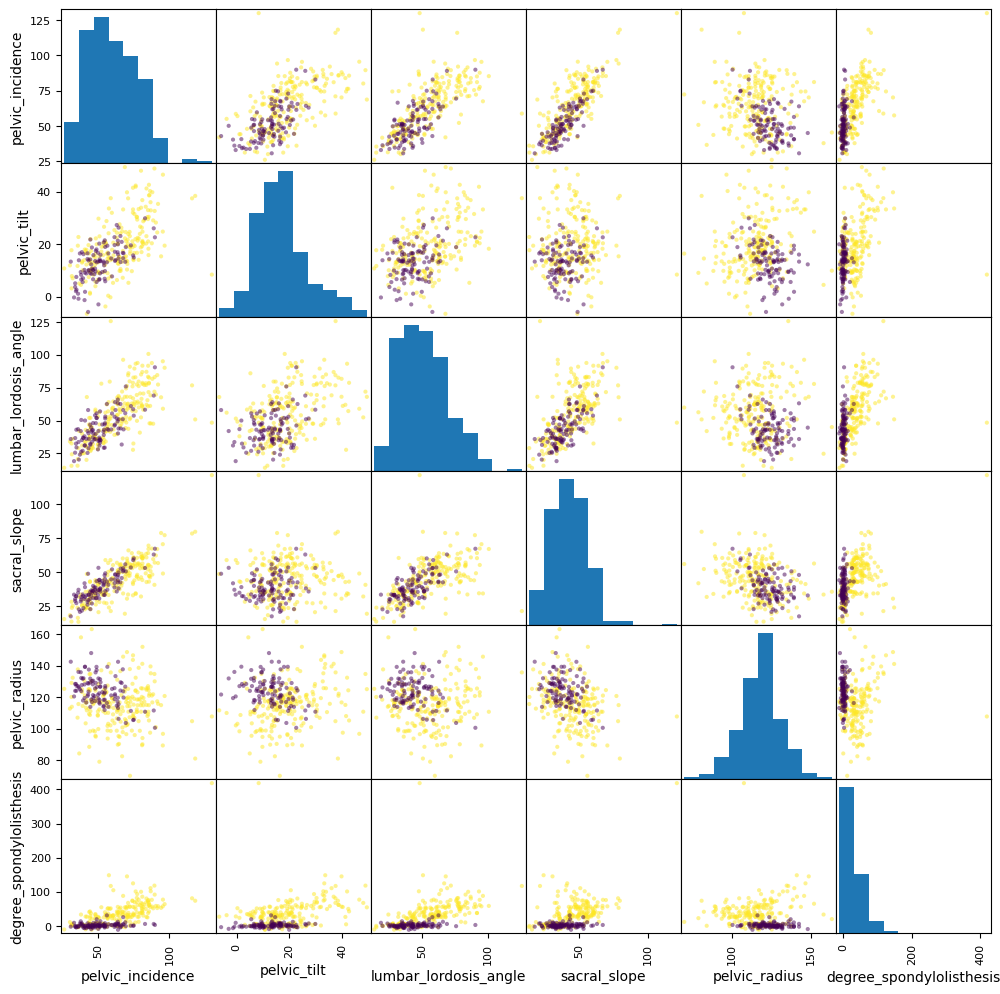

In [50]:
# So far here I have the following code:

# arff_file = arff.loadarff('vertebral_column_data/column_2C_weka.arff')

# df = pd.DataFrame(arff_file[0])

# df.head()

# print(df["class"])
# which gives the following results:
# 0      b'Abnormal' 1      b'Abnormal' 2      b'Abnormal' 3      b'Abnormal' 4      b'Abnormal'           ...      305      b'Normal' 306      b'Normal' 307      b'Normal' 308      b'Normal' 309      b'Normal' Name: class, Length: 310, dtype: object

# how do I change the abnormal to 1 and the normal class to 0

df["class"] = df["class"].str.decode("utf-8").map({
    "Abnormal": 1,
    "Normal": 0
})

# I want to make X and Y variables. what does this error mean:Can only use .str accessor with string values! print(df["class"]) X = df.loc[df["class"] == "1"] print(X) y = df.loc[df["class"] == "0"]
# print(df["class"].dtype)
X = df.loc[df["class"] == 1, ["class"]]
y = df.loc[df["class"] == 0, ["class"]]

# I am having trouble conceptualizing the idea of plotting 2 independent variables. I think i now have the two independent variables. X = df.loc[df["class"] == 1, ["class"]] y = df.loc[df["class"] == 0, ["class"]] Here is how I am trying to plot them: fig, ax = plt.subplots() ax.scatter(X, y) plt.show() How do I fix this and how do I change the colors as well
fig, ax = plt.subplots()
ax.scatter(df["pelvic_incidence"], df["pelvic_tilt"], c = df["class"])
plt.show()

# I have the two-feature scatterplot working: fig, ax = plt.subplots() ax.scatter(df["pelvic_incidence"], df["pelvic_tilt"], c = df["class"]) plt.show() how would i show a pairwise relationship among many variables?
# I tried the following:
# df_for_plot = df.loc[["pelvic_incidence", "pelvic_tilt", "lumbar_lordosis_angle", "sacral_slope", "pelvic_radius", "degree_spondylolisthesis"]]

# pd.plotting.scatter_matrix(df_for_plot)
# and got the following error:
# KeyError: "None of [Index(['pelvic_incidence', 'pelvic_tilt', 'lumbar_lordosis_angle',\n       'sacral_slope', 'pelvic_radius', 'degree_spondylolisthesis'],\n      dtype='object')] are in the [index]"

# how do i fix it
df_for_plot = df.loc[:,["pelvic_incidence", "pelvic_tilt", "lumbar_lordosis_angle", "sacral_slope", "pelvic_radius", "degree_spondylolisthesis"]]
# how do we add color to the grid
pd.plotting.scatter_matrix(df_for_plot, figsize=(12,12), c=df['class'])


#### ii. Boxplots

<Axes: >

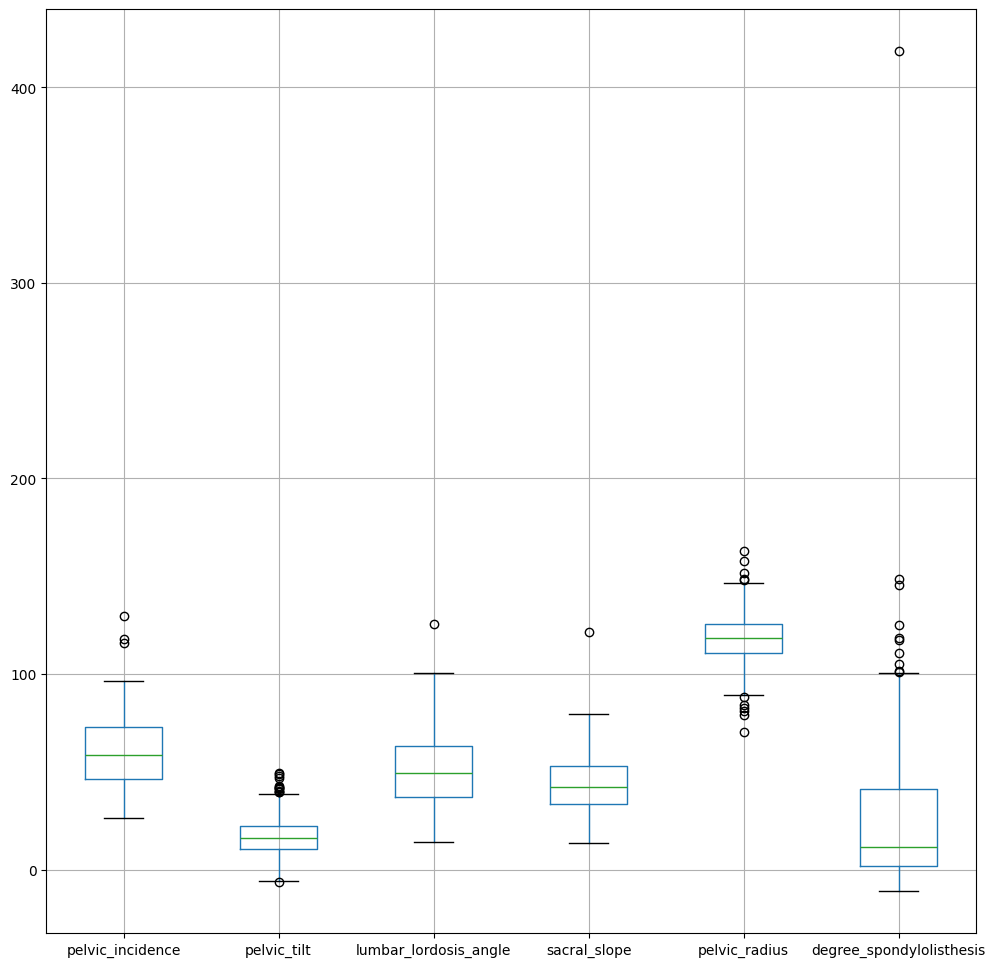

In [52]:
pd.plotting.boxplot(df_for_plot, figsize=(12,12))

#### iii. Split Data Set

In [ ]:
# did I split the data correctly:
# X_data = df.loc[(df["class"] == 1),["pelvic_incidence", "pelvic_tilt", "lumbar_lordosis_angle", "sacral_slope", "pelvic_radius", "degree_spondylolisthesis"]]
# X_training_data = X_data[:70]

# y_data = df.loc[(df["class"] == 0),["pelvic_incidence", "pelvic_tilt", "lumbar_lordosis_angle", "sacral_slope", "pelvic_radius", "degree_spondylolisthesis"]]
# y_training_data = y_data[:140]

# X_test_data = X_data[71:] 
# y_test_data = y_data[141:]

# I am trying to write code for knn. what am i doing wrong: training_data_0_X = training_data_0.loc[:, ["pelvic_incidence", "pelvic_tilt", "lumbar_lordosis_angle", "sacral_slope", "pelvic_radius", "degree_spondylolisthesis"]] training_data_0_y = training_data_0.loc[:, ["class"]] testing_data_0_X = testing_data_0.loc[:, ["pelvic_incidence", "pelvic_tilt", "lumbar_lordosis_angle", "sacral_slope", "pelvic_radius", "degree_spondylolisthesis"]] testing_data_0_y = testing_data_0.loc[:, ["class"]] knn = KNeighborsClassifier(n_neighbors=1, metric='euclidean') knn_pred = knn.fit(training_data_0_X, training_data_0_y).predict(testing_data_0_X) np.mean(testing_data_0_y != knn_pred)

class_0_data = df.loc[(df["class"] == 0),:]
training_data_0 = class_0_data.iloc[:70,:]
testing_data_0 = class_0_data.iloc[70:,:]

class_1_data = df.loc[(df["class"] == 1),:]
training_data_1 = class_1_data.iloc[:140,:]
testing_data_1 = class_1_data.iloc[140:,:]

training = pd.concat([training_data_0,training_data_1])
testing = pd.concat([testing_data_0,testing_data_1])
X_train = training.loc[:, ["pelvic_incidence", "pelvic_tilt", "lumbar_lordosis_angle", "sacral_slope", "pelvic_radius", "degree_spondylolisthesis"]]
y_train = training["class"]

X_test = testing.loc[:, ["pelvic_incidence", "pelvic_tilt", "lumbar_lordosis_angle", "sacral_slope", "pelvic_radius", "degree_spondylolisthesis"]]
y_test = testing["class"]



     pelvic_incidence  pelvic_tilt  lumbar_lordosis_angle  sacral_slope  \
210         38.505273    16.964297              35.112814     21.540976   
211         54.920858    18.968430              51.601455     35.952428   
212         44.362490     8.945435              46.902096     35.417055   
213         48.318931    17.452121              48.000000     30.866809   
214         45.701789    10.659859              42.577846     35.041929   
..                ...          ...                    ...           ...   
135         77.121344    30.349874              77.481083     46.771470   
136         88.024499    39.844669              81.774473     48.179830   
137         83.396606    34.310989              78.423293     49.085617   
138         72.054034    24.700737              79.874016     47.353297   
139         85.095503    21.069897              91.734792     64.025606   

     pelvic_radius  degree_spondylolisthesis  class  
210     127.632875                  7.986683 

### (c) Classification

#### i. Euclidean Metric

In [79]:
knn = KNeighborsClassifier(n_neighbors=1, metric='euclidean')
knn_pred = knn.fit(X_train, y_train).predict(X_test)
np.mean(y_test != knn_pred)

np.float64(0.13)

#### ii. Test Data

208
0.3
205
0.3
202
0.3
199
0.3
196
0.3
193
0.3
190
0.3
187
0.3
184
0.3
181
0.3
178
0.3
175
0.3
172
0.3
169
0.3
166
0.3
163
0.3
160
0.3
157
0.3
154
0.3
151
0.3
148
0.3
145
0.3
142
0.3
139
0.3
136
0.28
133
0.27
130
0.24
127
0.23
124
0.2
121
0.22
118
0.15
115
0.2
112
0.16
109
0.16
106
0.15
103
0.18
100
0.14
97
0.16
94
0.15
91
0.16
88
0.17
85
0.16
82
0.14
79
0.13
76
0.12
73
0.13
70
0.12
67
0.13
64
0.12
61
0.12
58
0.12
55
0.12
52
0.11
49
0.11
46
0.12
43
0.12
40
0.1
37
0.11
34
0.11
31
0.11
28
0.1
25
0.11
22
0.1
19
0.11
16
0.09
13
0.12
10
0.1
7
0.12
4
0.06


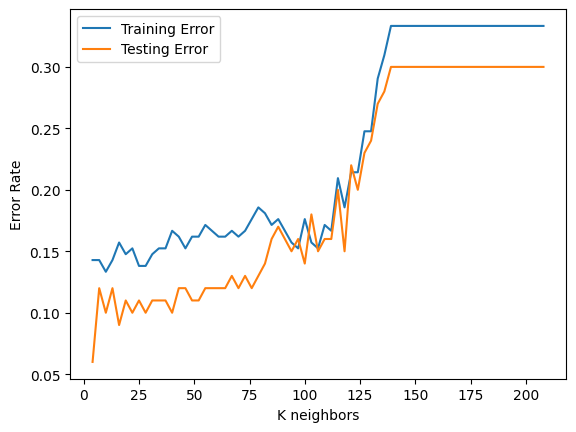

[[25  5]
 [ 1 69]]

true positive: 0.9857142857142858
true negative: 0.8333333333333334
precision: 0.9324324324324325
f1_score: 0.9583333333333334



In [108]:

Ks, train_errors, test_errors = [],[],[]

for K in range(208,1,-3):
    knn = KNeighborsClassifier(n_neighbors=K)
    knn_pred = knn.fit(X_train, y_train).predict(X_test)
    # temp = ('K={0:d}: # predicted abnormal: {1: >2}, ' + ' # of abnormal {2:d}, accuracy {3:.1%}')

    Ks.append(K)
    training_error = np.mean(y_train != knn.predict(X_train))
    testing_error = np.mean(y_test != knn_pred)
    print(K)
    print(testing_error)
    train_errors.append(training_error)
    test_errors.append(testing_error) 

plt.plot(Ks,train_errors)
plt.plot(Ks,test_errors)

plt.xlabel("K neighbors")
plt.ylabel("Error Rate")
plt.legend(["Training Error", "Testing Error"])

plt.show()

k_star_index = test_errors.index(min(test_errors))
k_star = Ks[k_star_index]

knn = KNeighborsClassifier(n_neighbors=k_star)
knn_pred = knn.fit(X_train, y_train).predict(X_test)
C = confusion_matrix(y_test, knn_pred)

TN, FP, FN, TP = C[0,0], C[0,1], C[1,0], C[1,1]
true_positive_rate = TP / (TP + FN)

true_negative_rate = TN / (TN + FP)

precision = TP / (TP + FP)

score = f1_score(y_test, knn_pred)

print(C)
print(f"""
true positive: {true_positive_rate}
true negative: {true_negative_rate}
precision: {precision}
f1_score: {score}
""")



    

#### iii. Learning Curve

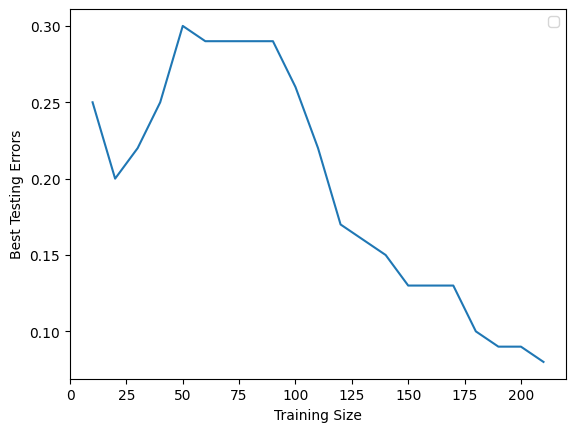

In [113]:
smallest_testing_errors = []

sizes = []
for N in range(10,211,10):
    Ks = []
    test_errors = []
    sizes.append(N)

    class_0_size = N//3
    class_1_size = N - (N//3)
    subset_train = pd.concat([training_data_0[:class_0_size], training_data_1[:class_1_size]])
    subset_X = subset_train.loc[:, ["pelvic_incidence", "pelvic_tilt", "lumbar_lordosis_angle", "sacral_slope", "pelvic_radius", "degree_spondylolisthesis"]]
    subtset_y = subset_train["class"]

    for K in range(1,N,5):

        knn = KNeighborsClassifier(n_neighbors=K)
        test_pred = knn.fit(subset_X, subtset_y).predict(X_test)

        testing_error = np.mean(test_pred != y_test)

        Ks.append(K)
        test_errors.append(testing_error)

    

    smallest_testing_errors.append(min(test_errors))

plt.xlabel("Training Size")
plt.ylabel("Best Testing Errors")
plt.legend(["Testing Error"])

plt.plot(sizes,smallest_testing_errors)

plt.show()

    

    

        

        



        

        

### (d) Other Metrics

#### i. Minkowski Distance.

##### A. Manhattan Distance with p = 1.

In [118]:
Ks = []
test_errors = []

for K in range(1,197,5):
    Ks.append(K)
    knn = KNeighborsClassifier(n_neighbors=K, metric='minkowski',p=1)
    test_pred = knn.fit(X_train,y_train).predict(X_test)

    testing_error = np.mean(test_pred != y_test)

    test_errors.append(testing_error)


optimal_k = Ks[test_errors.index(min(test_errors))]

Ks = np.array(Ks)
test_errors = np.array(test_errors)

table = pd.DataFrame({
    'K': Ks,
    'Testing Errors': test_errors
})

print(table)
print(optimal_k)


      K  Testing Errors
0     1            0.11
1     6            0.11
2    11            0.11
3    16            0.12
4    21            0.12
5    26            0.11
6    31            0.12
7    36            0.13
8    41            0.13
9    46            0.13
10   51            0.14
11   56            0.13
12   61            0.15
13   66            0.15
14   71            0.14
15   76            0.14
16   81            0.16
17   86            0.15
18   91            0.20
19   96            0.20
20  101            0.22
21  106            0.21
22  111            0.23
23  116            0.21
24  121            0.22
25  126            0.24
26  131            0.28
27  136            0.28
28  141            0.30
29  146            0.30
30  151            0.30
31  156            0.30
32  161            0.30
33  166            0.30
34  171            0.30
35  176            0.30
36  181            0.30
37  186            0.30
38  191            0.30
39  196            0.30
1


##### B. With log10(p) in {0.1, 0.2, 0.3, ... ,1}.

In [120]:
Ps = []
test_errors = []
P = 0.1
while P < 1.1:
    Ps.append(P)
    knn = KNeighborsClassifier(n_neighbors=1, metric='minkowski',p=P)
    test_pred = knn.fit(X_train,y_train).predict(X_test)

    testing_error = np.mean(test_pred != y_test)

    test_errors.append(testing_error)

    P += 0.1
optimal_p = Ps[test_errors.index(min(test_errors))]

Ps = np.array(Ps)
test_errors = np.array(test_errors)

table = pd.DataFrame({
    'P': Ps,
    'Testing Errors': test_errors
})

print(table)
print(optimal_p)

      P  Testing Errors
0   0.1            0.24
1   0.2            0.22
2   0.3            0.18
3   0.4            0.16
4   0.5            0.15
5   0.6            0.15
6   0.7            0.15
7   0.8            0.13
8   0.9            0.11
9   1.0            0.11
10  1.1            0.12
0.8999999999999999


/Users/bricepatchou/Documents/GitHub/DSCI552HW1/.venv/lib/python3.9/site-packages/sklearn/neighbors/_base.py:668: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
/Users/bricepatchou/Documents/GitHub/DSCI552HW1/.venv/lib/python3.9/site-packages/sklearn/neighbors/_base.py:668: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
/Users/bricepatchou/Documents/GitHub/DSCI552HW1/.venv/lib/python3.9/site-packages/sklearn/neighbors/_base.py:668: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(
/Users/bricepatchou/Documents/GitHub/DSCI552HW1/.venv/lib/python3.9/site-packages/sklearn/neighbors/_base.py:668: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing t

##### C. Chebyshev Distance With p -> infinity.

In [121]:
Ks = []
test_errors = []

for K in range(1,197,5):
    Ks.append(K)
    knn = KNeighborsClassifier(n_neighbors=K, metric='minkowski',p=np.inf)
    test_pred = knn.fit(X_train,y_train).predict(X_test)

    testing_error = np.mean(test_pred != y_test)

    test_errors.append(testing_error)


optimal_k = Ks[test_errors.index(min(test_errors))]

Ks = np.array(Ks)
test_errors = np.array(test_errors)

table = pd.DataFrame({
    'K': Ks,
    'Testing Errors': test_errors
})

print(table)
print(optimal_k)

      K  Testing Errors
0     1            0.13
1     6            0.10
2    11            0.12
3    16            0.08
4    21            0.11
5    26            0.12
6    31            0.12
7    36            0.10
8    41            0.13
9    46            0.12
10   51            0.12
11   56            0.12
12   61            0.14
13   66            0.13
14   71            0.14
15   76            0.11
16   81            0.14
17   86            0.12
18   91            0.15
19   96            0.14
20  101            0.19
21  106            0.18
22  111            0.18
23  116            0.18
24  121            0.21
25  126            0.21
26  131            0.25
27  136            0.28
28  141            0.30
29  146            0.30
30  151            0.30
31  156            0.30
32  161            0.30
33  166            0.30
34  171            0.30
35  176            0.30
36  181            0.30
37  186            0.30
38  191            0.30
39  196            0.30
16


#### ii. Mahalanobis Distance.

In [125]:
Ks = []
test_errors = []
covariance_matrix = np.cov(X_train, rowvar=False)
pseudo_inv_convariance_matric = np.linalg.pinv(covariance_matrix)
for K in range(1,197,5):
    Ks.append(K)
    knn = KNeighborsClassifier(n_neighbors=K, metric='mahalanobis', metric_params={'VI': pseudo_inv_convariance_matric})
    test_pred = knn.fit(X_train,y_train).predict(X_test)

    testing_error = np.mean(test_pred != y_test)

    test_errors.append(testing_error)


optimal_k = Ks[test_errors.index(min(test_errors))]

Ks = np.array(Ks)
test_errors = np.array(test_errors)

table = pd.DataFrame({
    'K': Ks,
    'Testing Errors': test_errors
})

print(table)
print(optimal_k)

      K  Testing Errors
0     1            0.15
1     6            0.16
2    11            0.18
3    16            0.17
4    21            0.20
5    26            0.17
6    31            0.21
7    36            0.21
8    41            0.19
9    46            0.22
10   51            0.21
11   56            0.21
12   61            0.23
13   66            0.21
14   71            0.22
15   76            0.21
16   81            0.24
17   86            0.21
18   91            0.24
19   96            0.24
20  101            0.24
21  106            0.23
22  111            0.25
23  116            0.26
24  121            0.29
25  126            0.29
26  131            0.30
27  136            0.30
28  141            0.30
29  146            0.30
30  151            0.30
31  156            0.30
32  161            0.30
33  166            0.30
34  171            0.30
35  176            0.30
36  181            0.30
37  186            0.30
38  191            0.30
39  196            0.30
1


### (e) Weighted Decision

### (f) Training Error Rate